In [71]:
import pandas as pd
import functions as f
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from scipy.stats import randint
import matplotlib.pyplot as plt

In [ ]:
## Leemos los datos, esta vez, de nuestro df más pequeño que exportamos la última vez
df = pd.read_csv('data/df_final.csv')

In [6]:
## Aplicamos nuestra función para dividir nuestro dataset en training and test
f.preparar_datos(df, target_col='es_viral', test_size=0.2, random_state=0)

[       rendimiento_promedio_media  num_enlaces  num_imgs  num_keywords  \
 8002                  3387.545041          9.0       1.0           7.0   
 3977                  2412.119932         25.0      11.0           8.0   
 32942                 4697.088251         30.0       1.0           4.0   
 33249                 2740.541021         21.0       2.0           8.0   
 29990                 3093.589689         12.0       1.0           6.0   
 ...                           ...          ...       ...           ...   
 20757                 3130.463537         20.0       3.0          10.0   
 32103                 4881.433290          7.0       0.0           7.0   
 30403                 5638.004127          0.0       0.0           4.0   
 21243                 2683.482028          9.0       2.0           7.0   
 2732                  2529.451129          7.0       0.0          10.0   
 
        subjetividad_global  fin_de_semana  polaridad_negativa_media  \
 8002              0.41404

In [7]:
X_train, X_test, y_train, y_test = f.preparar_datos(df, target_col='es_viral')

In [ ]:
## El modelo que mejor nos funcionó fue Gradient Boosting, pero solo con un 63,81 de exactitud. Vamos a intentar encontrar el mejor hiperarámetro para que nos funcione mejor. 

In [8]:
gbdt_clf = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, 
                                          max_depth=3, random_state=0)
gbdt_clf.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",3
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtype

In [9]:
pred_grd = gbdt_clf.predict(X_test)

In [10]:
print(f"Accuracy Gradient Boosting: {accuracy_score(y_test, pred_grd)}")

Accuracy Gradient Boosting: 0.6381637028629084


In [12]:
## Vamos a intnetar encontrar el mejor hiperparámetro aplicando un Grid

In [13]:
grid = {
    "max_iter": [50, 100, 200, 500],       
    "max_leaf_nodes": [31, 64, 127, None], 
    "max_depth": [5, 10, 20, None]
}

In [14]:
hist_gradient = HistGradientBoostingClassifier(random_state=0)

In [17]:
model = GridSearchCV(estimator=hist_gradient, param_grid=grid, cv=5, n_jobs=-1)

In [19]:
model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_iter': [50, 100, ...], 'max_leaf_nodes': [31, 64, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [20]:
model.best_params_

{'max_depth': 5, 'max_iter': 100, 'max_leaf_nodes': 31}

In [21]:
best_model = model.best_estimator_

In [26]:
pred = model.predict(X_test)

print("MAE", mean_absolute_error(pred, y_test))
print("R2 score", model.score(X_test, y_test))

MAE 0.35805271787110604
R2 score 0.641947282128894


In [27]:
print("Mejores parámetros encontrados:")
print(model.best_params_)

print(f"\nMejor puntuación (accuracy/score) en validación: {model.best_score_:.4f}")

Mejores parámetros encontrados:
{'max_depth': 5, 'max_iter': 100, 'max_leaf_nodes': 31}

Mejor puntuación (accuracy/score) en validación: 0.6458


In [28]:
## Se mejora un poco con estos nuevos hiperparámetros: 
mejor_gbdt = HistGradientBoostingClassifier(
    max_depth=5, 
    max_iter=100, 
    max_leaf_nodes=31, 
    random_state=0
)

mejor_gbdt.fit(X_train, y_train)
final_pred = mejor_gbdt.predict(X_test)
print(f"Accuracy final: {accuracy_score(y_test, final_pred)}")

Accuracy final: 0.641947282128894


In [29]:
## Sin embargo, me gustaría probar si otro modelo, con hiperpaámetros cambiados, puede mejorar aun más. La diferencia entre gradient boosting y Random Forest era mínima, así que intentemos repetir el proceso pero con random forest.

#### Probando Grid con Random Forest

In [31]:
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, 
                                 n_jobs=-1, random_state=0)
rnd_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",16
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [32]:
pred_rnd = rnd_clf.predict(X_test)

In [33]:
print(f"Accuracy Random Forest: {accuracy_score(y_test, pred_rnd)}")

Accuracy Random Forest: 0.6360196746121831


In [47]:
rnd_forest = RandomForestClassifier(random_state=42)

In [48]:
grid_rnd = grid_rf = {
    "n_estimators": [100, 200, 500],        
    "max_leaf_nodes": [31, 64, 127, None],
    "max_depth": [5, 10, 20, None]      
}

In [51]:
model_rnd = GridSearchCV(estimator = rnd_forest, param_grid = grid_rnd, cv=5)

In [52]:
model_rnd.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_leaf_nodes': [31, 64, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [53]:
model_rnd.best_params_

{'max_depth': 20, 'max_leaf_nodes': 127, 'n_estimators': 200}

In [54]:
new_model = model_rnd.best_estimator_

In [87]:
pred_new = model_rnd.predict(X_test)
recall_grid = recall_score(y_test, pred_new)

print("MAE", mean_absolute_error(pred_rnd, y_test))
print("R2 score", model_rnd.score(X_test, y_test))
print(f"Recall grid search: {recall_grid:.4f}")


MAE 0.3639803253878169
R2 score 0.6382898221717745
Recall grid search: 0.6394


In [57]:
print("Mejores parámetros encontrados:")
print(model_rnd.best_params_)

print(f"\nMejor puntuación (accuracy/score) en validación: {model_rnd.best_score_:.4f}")

Mejores parámetros encontrados:
{'max_depth': 20, 'max_leaf_nodes': 127, 'n_estimators': 200}

Mejor puntuación (accuracy/score) en validación: 0.6462


In [60]:
## Por muy poco, pero con estos parámetros Random Forest supera al anterior modelo (64,58 frente a 64,62)

In [61]:
features = df.drop(columns = ["es_viral"])
target = df["es_viral"]

In [69]:
df.shape

(39644, 11)

### Aplicamos Random Search a Random Forest (MODEL)

In [72]:
param_dist = {
    'n_estimators': randint(100, 1000),      
    'max_depth': [None, 10, 20, 30, 40, 50],
    'max_leaf_nodes': randint(31, 500),      
    'min_samples_split': randint(2, 20),     
    'bootstrap': [True, False]               
}

model_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,           
    cv=5, 
    random_state=0, 
    n_jobs=-1,
    verbose=1            # Para ver el progreso mientras busca (añadido-buscado)
)

# Entrenamos con los nuevos rangos
model_random_search.fit(X_train, y_train)

print(f"Mejores parámetros: {model_random_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores parámetros: {'bootstrap': True, 'max_depth': 30, 'max_leaf_nodes': 498, 'min_samples_split': 16, 'n_estimators': 248}


In [82]:
pred_random = model_random_search.predict(X_test)
accuracy_random = accuracy_score(y_test, pred_random)
mae_random = mean_absolute_error(y_test, pred_random)
recall_random = recall_score(y_test, pred_random)

In [83]:
print(f"Accuracy: {accuracy_random}")
print(f"Error (MAE): {mae_random}")
print(f"Recall Random Search: {recall_random:.4f}")
print(f"Mejores parámetros: {model_random_search.best_params_}")

Accuracy: 0.6424517593643587
Error (MAE): 0.35754824063564133
Recall Random Search: 0.6358
Mejores parámetros: {'bootstrap': True, 'max_depth': 30, 'max_leaf_nodes': 498, 'min_samples_split': 16, 'n_estimators': 248}


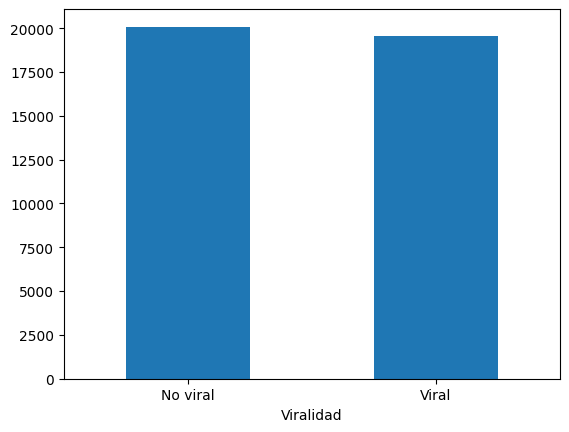

In [ ]:
## Comprobamos el balance, por si pudiéramos mejorarlo. 
viralidad = target.value_counts()
viralidad.plot(kind="bar")
plt.xticks([0, 1], ['No viral', 'Viral'], rotation=0)
plt.xlabel('Viralidad')
plt.show()

In [85]:
## Aparentemente la mejor exactitud es la del modelo Random Forest con los hiperparámetros: Mejores parámetros: {'bootstrap': True, 'max_depth': 30, 'max_leaf_nodes': 498, 'min_samples_split': 16, 'n_estimators': 248}